## 64607068 Surasak Chantarach

#**Car Insurance Dataset**

บริษัทประกันแห่งหนึ่งต้องการให้คุณช่วยสร้าง model สำหรับทำนายว่าลูกค้าผู้ซื้อกรมธรรม์ประกันสุขภาพในปีก่อน จะมีความสนใจในกรมธรรม์ตัวใหม่ของบริษัท - ประกันอุบัติเหตุรถยนต์ หรือไม่

หลังจากที่ผู้เอาประกัน ได้ทำการตกลงทำตามข้อสัญญา กับทางบริษัทประกันเป็นที่เรียบร้อยแล้ว ผู้เอาประกัน จะต้องมีการจ่ายค่าตอบแทน (premium) ให้กับผู้รับประกัน ซึ่งก็คือบริษัทประกัน ตามจำนวนเงินในสัญญาภายในกรมธรรม์ (policy) และเมื่อเกิดอุบัติเหตุ บาดเจ็บ เสียทรัพย์ ไปจนถึงเสียชีวิต บริษัทประกัน จะทำการวิเคราะห์เหตุการณ์ และตีค่าออกมาเป็นตัวเงินก่อนจะชดเชยให้กับผู้เอาประกัน หรือผู้รับผลประโยชน์ ตามจำนวนเงินในเงื่อนไขภายในกรมธรรม์

### Data Description

| Variable | Definition |
| -------- | ---------- |
| id |	Unique ID for the customer |
| Gender |	Gender of the customer |
| Age |	Age of the customer |
| Driving_License |	0 : Customer does not have Driving License, <br> 1 : Customer already has Driving License |
| Region_Code |	Unique code for the region of the customer |
| Previously_Insured |	1 : Customer already has Vehicle Insurance, <br> 0 : Customer doesn't have Vehicle Insurance
| Vehicle_Age |	Age of the Vehicle |
| Vehicle_Damage |	1 : Customer got his/her vehicle damaged in the past. <br> 0 : Customer did not get his/her vehicle damaged in the past. |
| Annual_Premium |	The amount customer needs to pay as premium in the year |
| PolicySalesChannel |	Anonymized Code for the channel of outreaching to the customer ie <br> Different Agents, Over Mail, Over Phone, In Person, etc. |
| Vintage |	Number of Days, Customer has been associated with the company |
| Response |	1 : Customer is interested, <br> 0 : Customer is not interested |

### Remark
- ข้อมูล feature บางตัวมีลักษณะเป็นตัวแปรหมวดหมู่ควรมีการทำตัวแปร dummy
- ข้อมูล target class 0 และ 1 มีจำนวนแตกต่างกันมาก

### Objective:
**ให้สร้าง model เพื่อทำนายว่าลูกค้าจะสนใจซื้อกรมธรรม์ประกันอุบัติเหตุรถยนต์หรือไม่**

#**0. Import Library & Load Dataset**

In [4]:
import sys
import warnings
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

if not sys.warnoptions:
    warnings.simplefilter("ignore")

from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib
import re
import seaborn as sns

# General pandas options
pd.set_option('display.max_colwidth', -1)  # Show the entire column
pd.options.display.max_columns = 100
pd.options.display.max_rows = 10000

from scipy import stats
# from functools import reduce

# Some matplotlib options
%matplotlib inline
matplotlib.style.use("ggplot")

# Seaborn options
sns.set_style("whitegrid")
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, auc, roc_curve
from sklearn import model_selection, tree, preprocessing ,metrics
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


from sklearn.ensemble import ExtraTreesClassifier # feature importance
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, learning_curve, cross_validate, train_test_split, KFold, cross_val_score


<ipython-input-4-1da48fe4cb40>:16: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option('display.max_colwidth', -1)  # Show the entire column


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv('/content/insurance_data.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113253 entries, 0 to 113252
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    113253 non-null  int64  
 1   Gender                113253 non-null  object 
 2   Age                   113253 non-null  int64  
 3   Driving_License       113253 non-null  int64  
 4   Region_Code           113253 non-null  float64
 5   Previously_Insured    113253 non-null  int64  
 6   Vehicle_Age           113253 non-null  object 
 7   Vehicle_Damage        113253 non-null  object 
 8   Annual_Premium        113252 non-null  float64
 9   Policy_Sales_Channel  113252 non-null  float64
 10  Vintage               113252 non-null  float64
 11  Response              113252 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 10.4+ MB


In [8]:
# ดูจำนวน row
print(df.shape)

(113253, 12)


In [9]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217.0,1.0
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183.0,0.0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27.0,1.0
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203.0,0.0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39.0,0.0


In [10]:
# include='all' แสดงทุก data types
df.describe(include='all')

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,113253.000000,113253,113253.000000,113253.000000,113253.000000,113253.000000,113253,113253,113252.000000,113252.000000,113252.000000,113252.000000
unique,NaN,2,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,1-2 Year,Yes,NaN,NaN,NaN,NaN
freq,NaN,61049,NaN,NaN,NaN,NaN,59465,57347,NaN,NaN,NaN,NaN
mean,56627.000000,NaN,38.806195,0.998049,26.422682,0.456527,NaN,NaN,30460.738168,112.206813,154.360170,0.123132
std,32693.469356,NaN,15.483869,0.044132,13.229973,0.498109,NaN,NaN,17150.701222,54.119404,83.809574,0.328591
min,1.000000,NaN,20.000000,0.000000,0.000000,0.000000,NaN,NaN,2630.000000,1.000000,10.000000,0.000000
25%,28314.000000,NaN,25.000000,1.000000,15.000000,0.000000,NaN,NaN,24330.000000,29.000000,82.000000,0.000000
50%,56627.000000,NaN,36.000000,1.000000,28.000000,0.000000,NaN,NaN,31613.000000,136.500000,154.000000,0.000000
75%,84940.000000,NaN,49.000000,1.000000,35.000000,1.000000,NaN,NaN,39362.500000,152.000000,227.000000,0.000000


#**1. Data Cleansing**

## Check Null Value

In [11]:
# Check missing value: มี missing values ทั้ง 12 column
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          1
Policy_Sales_Channel    1
Vintage                 1
Response                1
dtype: int64

In [12]:
# Using isna() to select all rows with NaN under an entire DataFrame:
print("All Rows, Columns ==> ", df.shape)
print("Count NA:", df.isna().sum().sum(), " rows")
df.isna().sum()

All Rows, Columns ==>  (113253, 12)
Count NA: 4  rows


id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          1
Policy_Sales_Channel    1
Vintage                 1
Response                1
dtype: int64

In [13]:
# Drop NA ท้ิงทั้งแถว
df.dropna(axis=0, inplace=True)

print("Remaining Rows, Columns ==> ", df.shape)
print("Count NA:", df.isna().sum().sum(), " rows")
df.isna().sum()

Remaining Rows, Columns ==>  (113252, 12)
Count NA: 0  rows


id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

## Check Duplicated Value

In [14]:
# Check duplicated value: 28 row
print("Duplicated Rows: ", df[df.duplicated(keep=False)].shape)

# # Drop duplicated Value
# df.drop_duplicates(inplace=True)

# print("Remaining Rows: ", df.shape)
# df.describe()

Duplicated Rows:  (0, 12)


## Trim/Strip Value

In [15]:
# Strip whitespaces/Trim ด้วย short function: lamda
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [16]:
# Check Type ที่ยังไม่ตรง
df.dtypes
# They all hould be "Binary": Attrition, Over18, OverTime

id                      int64  
Gender                  object 
Age                     int64  
Driving_License         int64  
Region_Code             float64
Previously_Insured      int64  
Vehicle_Age             object 
Vehicle_Damage          object 
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                 float64
Response                float64
dtype: object

In [17]:
# Using isna() to select all rows with NaN under an entire DataFrame:
print("All Rows, Columns ==> ", df.shape)
print("Count NA:", df.isna().sum().sum(), " rows")
df.isna().sum()

All Rows, Columns ==>  (113252, 12)
Count NA: 0  rows


id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [18]:
# ดูสถติ ของแต่ล่ะ feature
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,113252.00000,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000
mean,56626.50000,38.806078,0.998049,26.422659,0.456531,30460.738168,112.206813,154.360170,0.123132
std,32693.18068,15.483888,0.044132,13.230030,0.498109,17150.701222,54.119404,83.809574,0.328591
min,1.00000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,28313.75000,25.000000,1.000000,15.000000,0.000000,24330.000000,29.000000,82.000000,0.000000
50%,56626.50000,36.000000,1.000000,28.000000,0.000000,31613.000000,136.500000,154.000000,0.000000
75%,84939.25000,49.000000,1.000000,35.000000,1.000000,39362.500000,152.000000,227.000000,0.000000
max,113252.00000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [19]:
df.dropna(axis=1, how='all')

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217.0,1.0
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183.0,0.0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27.0,1.0
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203.0,0.0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
113247,113248,Male,21,1,9.0,1,< 1 Year,No,38584.0,160.0,64.0,0.0
113248,113249,Female,43,1,28.0,0,1-2 Year,Yes,30241.0,124.0,219.0,0.0
113249,113250,Female,61,1,28.0,0,1-2 Year,Yes,49766.0,26.0,164.0,0.0
113250,113251,Female,22,1,16.0,1,< 1 Year,Yes,31302.0,152.0,96.0,0.0


## Remove Uniqe/Key and Irrelevant

In [20]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217.0,1.0
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183.0,0.0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27.0,1.0
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203.0,0.0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39.0,0.0


In [21]:
# ทำการลบ Unique
df = df.drop(['id'], 1)

<ipython-input-21-b0eb9d8cb18b>:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df = df.drop(['id'], 1)


In [22]:
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217.0,1.0
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183.0,0.0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27.0,1.0
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203.0,0.0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39.0,0.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 113252 entries, 0 to 113251
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                113252 non-null  object 
 1   Age                   113252 non-null  int64  
 2   Driving_License       113252 non-null  int64  
 3   Region_Code           113252 non-null  float64
 4   Previously_Insured    113252 non-null  int64  
 5   Vehicle_Age           113252 non-null  object 
 6   Vehicle_Damage        113252 non-null  object 
 7   Annual_Premium        113252 non-null  float64
 8   Policy_Sales_Channel  113252 non-null  float64
 9   Vintage               113252 non-null  float64
 10  Response              113252 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 10.4+ MB


#**2. EDA: Exploratory Data Analysis**

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 113252 entries, 0 to 113251
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                113252 non-null  object 
 1   Age                   113252 non-null  int64  
 2   Driving_License       113252 non-null  int64  
 3   Region_Code           113252 non-null  float64
 4   Previously_Insured    113252 non-null  int64  
 5   Vehicle_Age           113252 non-null  object 
 6   Vehicle_Damage        113252 non-null  object 
 7   Annual_Premium        113252 non-null  float64
 8   Policy_Sales_Channel  113252 non-null  float64
 9   Vintage               113252 non-null  float64
 10  Response              113252 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 10.4+ MB


In [25]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [26]:
df[numeric_cols].head()

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,44,1,28.0,0,40454.0,26.0,217.0,1.0
1,76,1,3.0,0,33536.0,26.0,183.0,0.0
2,47,1,28.0,0,38294.0,26.0,27.0,1.0
3,21,1,11.0,1,28619.0,152.0,203.0,0.0
4,29,1,41.0,1,27496.0,152.0,39.0,0.0


In [27]:
df[categorical_cols].head()

,Gender,Vehicle_Age,Vehicle_Damage
0,Male,> 2 Years,Yes
1,Male,1-2 Year,No
2,Male,> 2 Years,Yes
3,Male,< 1 Year,No
4,Female,< 1 Year,No


In [28]:
# ตรวจสอบ missing value อีกครั้ง
missing_counts = df[numeric_cols].isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

Series([], dtype: int64)

In [29]:
missing_counts = df[categorical_cols].isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

Series([], dtype: int64)

In [30]:
# ดูค่าทางสถิติของ feature ที่เป็นตัวเลข
df[numeric_cols].describe()

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000,113252.000000
mean,38.806078,0.998049,26.422659,0.456531,30460.738168,112.206813,154.360170,0.123132
std,15.483888,0.044132,13.230030,0.498109,17150.701222,54.119404,83.809574,0.328591
min,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,24330.000000,29.000000,82.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,31613.000000,136.500000,154.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,39362.500000,152.000000,227.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


###**Target Variable**

เกิด imbalance ตัว Response. โดยจะทำงาน down sample data เพื่อเพิ่ม accuracy.

In [31]:
# นัับจำนวน Label
df['Response'].value_counts()

0.0    99307
1.0    13945
Name: Response, dtype: int64

In [32]:
def count_plot(df,feat,palette='rainbow'):
    plt.style.use('seaborn')
    sns.set_style('whitegrid')

    labels=df[feat].value_counts().index
    values=df[feat].value_counts().values

    plt.figure(figsize=(15,5))

    ax = plt.subplot2grid((1,2),(0,0))
    sns.barplot(x=labels, y=values,palette=palette, alpha=0.75)
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2., height + 0.1, values[i],ha="center")
    plt.title('Response of Customer', fontsize=15, weight='bold')
    plt.show()

<ipython-input-32-9089b74788e1>:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


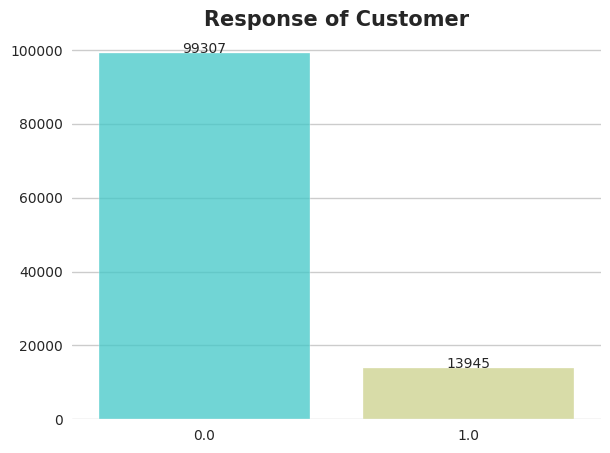

In [33]:
sns.set_style("whitegrid")
count_plot(df,'Response')

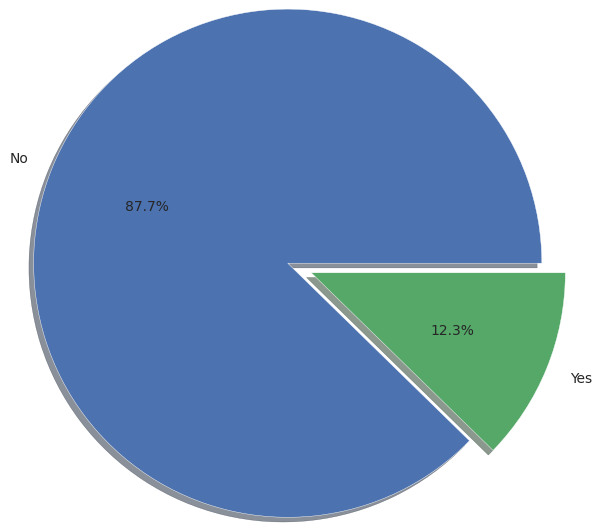

In [34]:
r = df.groupby('Response')['Response'].count()
plt.pie(r, explode=[0.05, 0.1], labels=['No', 'Yes'], radius=1.5, autopct='%1.1f%%',  shadow=True);

###Gender
Gender distribution มีความ balance



<ipython-input-32-9089b74788e1>:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


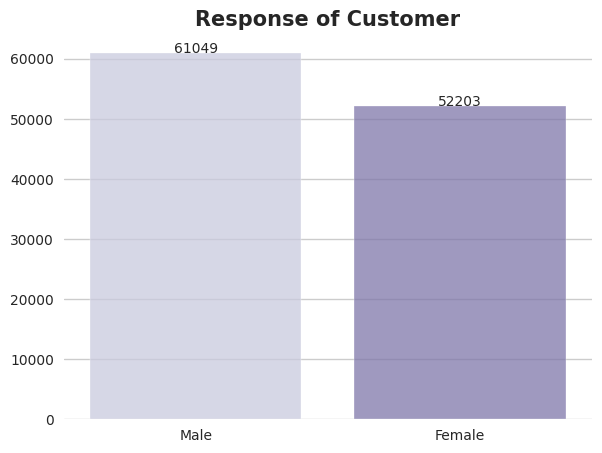

In [35]:
count_plot(df,'Gender','Purples')
plt.show()

ผู้ชาย จะค่อนข้าง สนใจ มากกว่ากว่า ผู้หญิง

<Axes: xlabel='Gender', ylabel='count'>

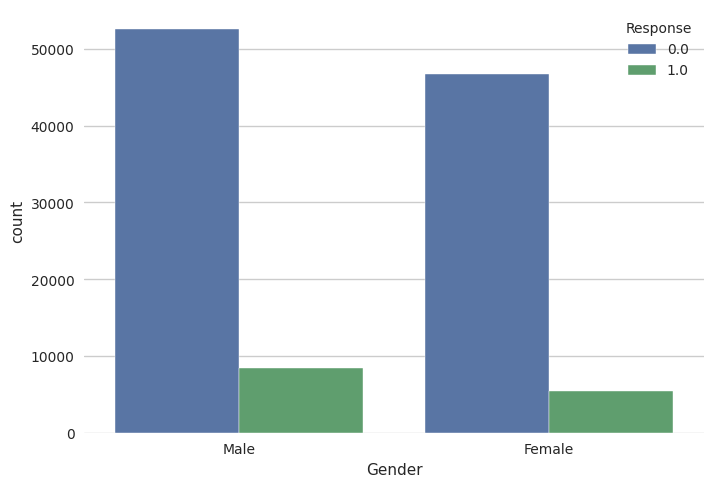

In [36]:
sns.countplot(data=df,x='Gender',hue='Response')


### Gender vs Driving License
ผู้ชาย จะมีใบอนุญาตขับขี่มากกว่า ผู้หญิง

In [37]:
df_gender = df.groupby(['Gender'])['Driving_License'].count().to_frame().reset_index()
df_gender

,Gender,Driving_License
0,Female,52203
1,Male,61049


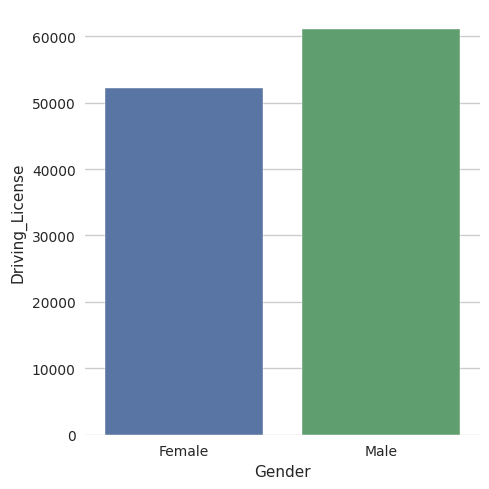

In [38]:
df_gender2 = df.groupby(['Gender'])['Driving_License'].count().to_frame().reset_index()
sns.catplot(x="Gender", y="Driving_License",
                data=df_gender2, kind="bar");

###Age Groups
Age จะค่อนข้าง effect กับ response target var

<ipython-input-39-f56b2f1fd677>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df.Response==0]['Age'], label='0')
<ipython-input-39-f56b2f1fd677>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df.Response==1]['Age'], label='1')


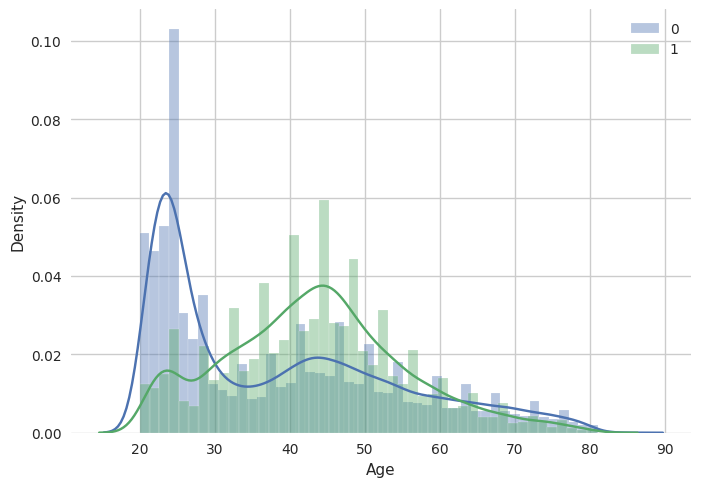

In [39]:
sns.distplot(df[df.Response==0]['Age'], label='0')
sns.distplot(df[df.Response==1]['Age'], label='1')
plt.legend()
plt.show()

บางช่วงอายุ จะมีความสำคัญใน dataset นี้

###Age vs Vehicle Damage
ผู้สูงอายุ มีเกิดอบัติทางรถยนต์ ตามด้านล่าง

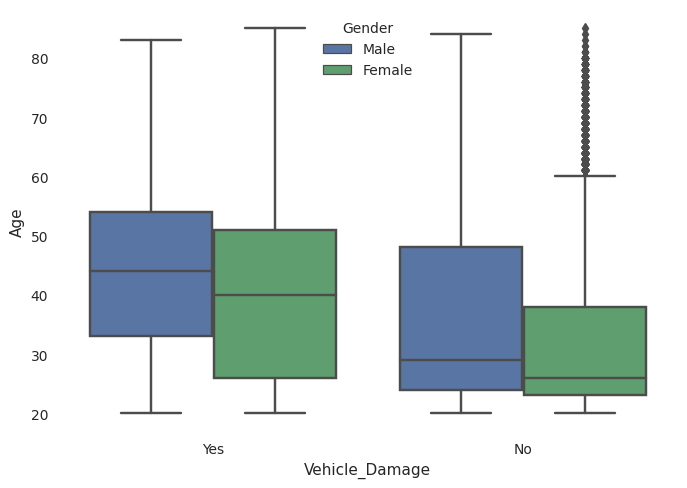

In [40]:
with sns.axes_style(style='ticks'):
  g = sns.boxplot( x="Vehicle_Damage", y="Age", hue="Gender", data=df)
  # g.set_ylabels("Vehicle_Damage", "Age");

###Age vs Previously Insured
ช่วงอายุ > 80 และ 23-25 ปี จะประกันก่อนหน้านี้อยู่แล้ว



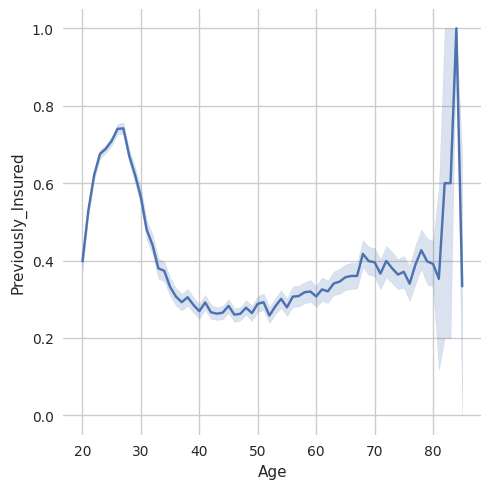

In [41]:
sns.relplot(data=df,x='Age',y='Previously_Insured',kind='line')

### Vehicle Age vs Vehicle Damage
อายุรถ และ จำนวนที่เกิดความเสียหาย จะมากอยู่ที่ 1-2 ปี ของอายุรถ


<Axes: xlabel='Vehicle_Age', ylabel='count'>

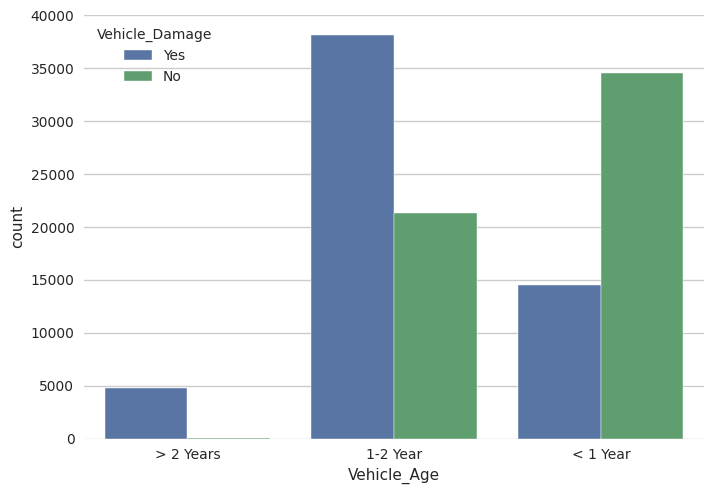

In [42]:
sns.countplot(data = df,x='Vehicle_Age',hue='Vehicle_Damage')

###Count Vehicle Age vs Response

In [43]:
df1 = df.groupby(['Vehicle_Age','Response'])['Response'].count().to_frame().rename(columns={'Response':'Count'}).reset_index()
df1

,Vehicle_Age,Response,Count
0,1-2 Year,0.0,49087
1,1-2 Year,1.0,10377
2,< 1 Year,0.0,46894
3,< 1 Year,1.0,2144
4,> 2 Years,0.0,3326
5,> 2 Years,1.0,1424


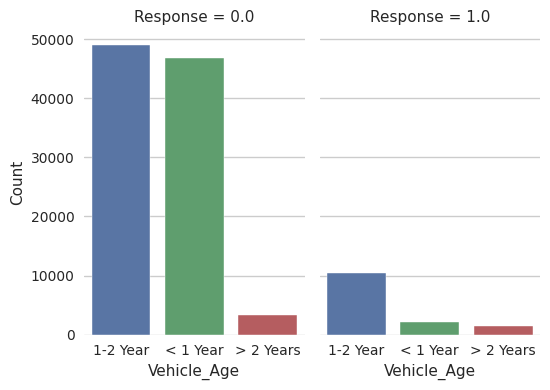

In [44]:
g = sns.catplot(x="Vehicle_Age", y="Count",col="Response",
                data=df1, kind="bar",
                height=4, aspect=.7);

###Cunt Vehicle Damage vs Response
สัดส่วนของกลุ่ม Response=0 จะเกิดความเสียหายกับยานพาหนะจะสูงกว่า


In [45]:
df_vh_damage = df.groupby(['Vehicle_Damage','Response'])['Response'].count().to_frame().rename(columns={'Response':'count'}).reset_index()
df_vh_damage

,Vehicle_Damage,Response,count
0,No,0.0,55626
1,No,1.0,279
2,Yes,0.0,43681
3,Yes,1.0,13666


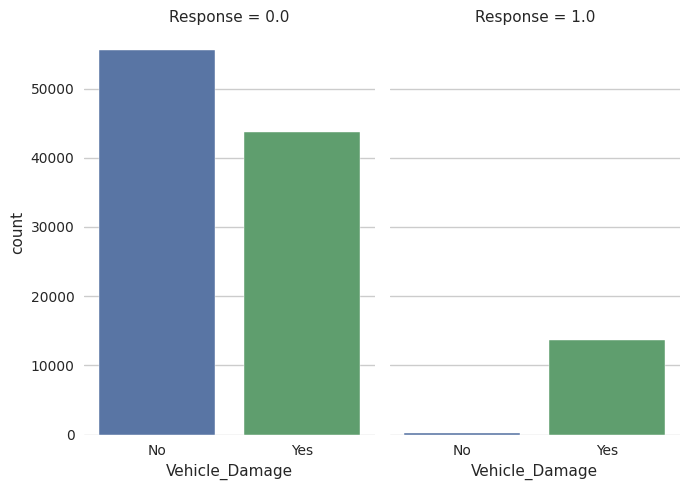

In [46]:
g = sns.catplot(x="Vehicle_Damage", y="count",col="Response",
                data=df_vh_damage, kind="bar",aspect=0.7)

###Annual Premium Distribution



<ipython-input-47-0bf0251046cf>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Annual_Premium'])


<Axes: xlabel='Annual_Premium', ylabel='Density'>

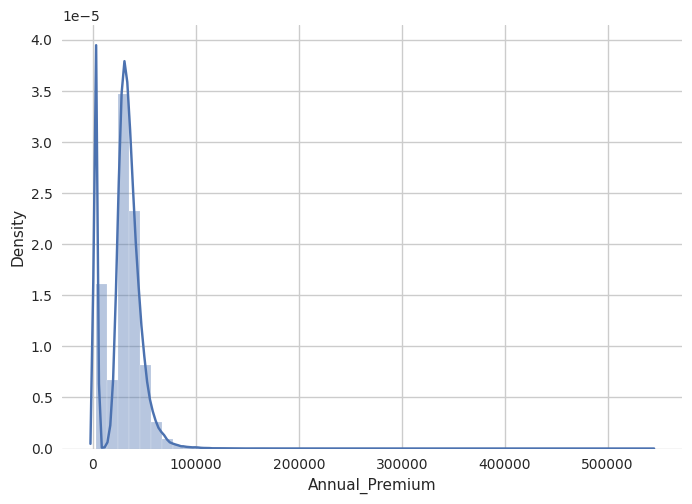

In [47]:
# The amount customer needs to pay as premium in the year
sns.distplot(df['Annual_Premium'])

###Vintage


<ipython-input-48-26d39643ff9c>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Vintage'])


<Axes: xlabel='Vintage', ylabel='Density'>

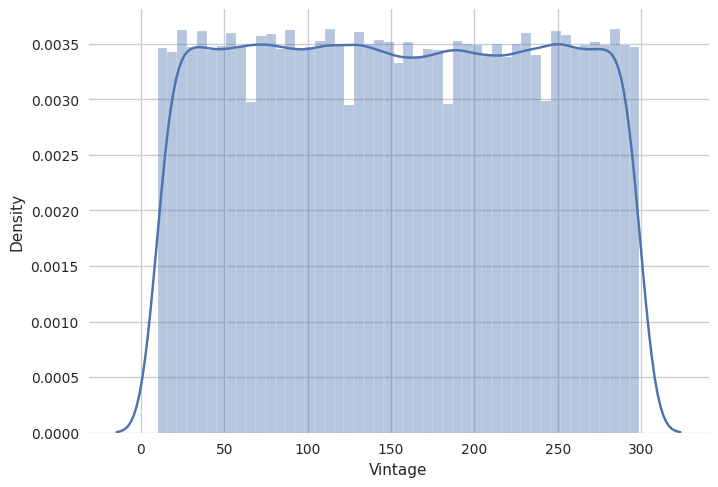

In [48]:
# Number of Days, Customer has been associated with the company
sns.distplot(df['Vintage'])

#**3. Data Preprocessing**



##Convert Categorical data to be numeric data

In [49]:
df.dtypes

Gender                  object 
Age                     int64  
Driving_License         int64  
Region_Code             float64
Previously_Insured      int64  
Vehicle_Age             object 
Vehicle_Damage          object 
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                 float64
Response                float64
dtype: object

**Gener**

In [50]:
df['Gender'] = df['Gender'].replace({'Male':1,'Female':0})
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217.0,1.0
1,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183.0,0.0
2,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27.0,1.0
3,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203.0,0.0
4,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39.0,0.0


**Vehicle_Age**

In [51]:
df['Vehicle_Age'].unique()

array(['> 2 Years', '1-2 Year', '< 1 Year'], dtype=object)

In [52]:
df['Vehicle_Age'] = df['Vehicle_Age'].replace({'< 1 Year':1,'1-2 Year':2, '> 2 Years':3})
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,3,Yes,40454.0,26.0,217.0,1.0
1,1,76,1,3.0,0,2,No,33536.0,26.0,183.0,0.0
2,1,47,1,28.0,0,3,Yes,38294.0,26.0,27.0,1.0
3,1,21,1,11.0,1,1,No,28619.0,152.0,203.0,0.0
4,0,29,1,41.0,1,1,No,27496.0,152.0,39.0,0.0


**Vehicle_Damage**

In [53]:
df['Vehicle_Damage'].replace({'Yes':1,'No':0},inplace=True)
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,3,1,40454.0,26.0,217.0,1.0
1,1,76,1,3.0,0,2,0,33536.0,26.0,183.0,0.0
2,1,47,1,28.0,0,3,1,38294.0,26.0,27.0,1.0
3,1,21,1,11.0,1,1,0,28619.0,152.0,203.0,0.0
4,0,29,1,41.0,1,1,0,27496.0,152.0,39.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
113247,1,21,1,9.0,1,1,0,38584.0,160.0,64.0,0.0
113248,0,43,1,28.0,0,2,1,30241.0,124.0,219.0,0.0
113249,0,61,1,28.0,0,2,1,49766.0,26.0,164.0,0.0
113250,0,22,1,16.0,1,1,1,31302.0,152.0,96.0,0.0


In [54]:
df.dtypes

Gender                  int64  
Age                     int64  
Driving_License         int64  
Region_Code             float64
Previously_Insured      int64  
Vehicle_Age             int64  
Vehicle_Damage          int64  
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                 float64
Response                float64
dtype: object

##Correlations

<ipython-input-55-971b0341e4f2>:8: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros_like(corr, dtype=np.bool)


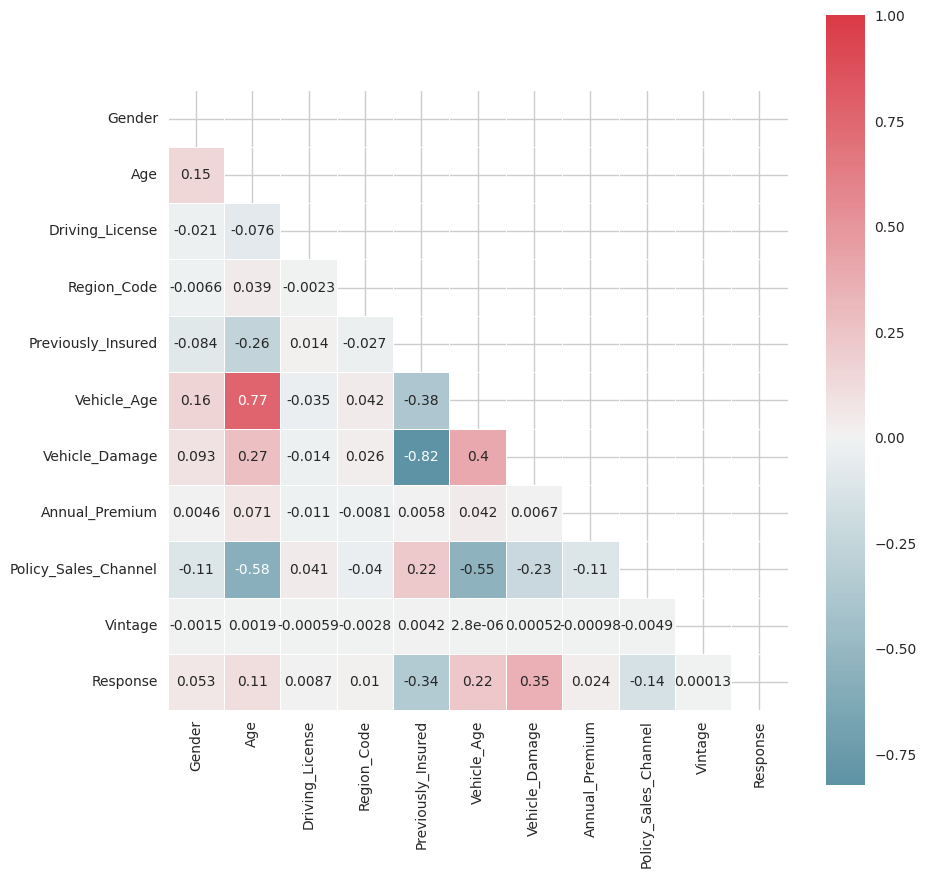

In [55]:
# Subset the dataset into all the numerical values
numeric_hr = df.select_dtypes(include=[np.number])

# Compete the correlation matrix
corr = numeric_hr._get_numeric_data().corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
heatmap = sns.heatmap(corr, annot=True, mask=mask, cmap=cmap, center=0.0,
                      vmax = 1, square=True, linewidths=.5, ax=ax)
plt.savefig('corr-heat.png')
plt.show()

#**4. Splitting the Data**
Set Features

In [56]:
# Importance Features ( 7/10)
X = df[['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage']]
y = df['Response']

In [57]:
y.value_counts()

0.0    99307
1.0    13945
Name: Response, dtype: int64

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=101)

print("Train Shape:", X_train.shape, y_train.shape)
print("Test set Shape:", X_test.shape, y_test.shape)

Train Shape: (90601, 10) (90601,)
Test set Shape: (22651, 10) (22651,)


#**5. Oversampling**

In [59]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import ADASYN

#ros = RandomOverSampler(random_state=42, sampling_strategy='minority')
#all_train_enc_over_sampled, y_train_over_sampled = ros.fit_resample(all_train_enc, y_train)

ada = ADASYN(random_state=101)
all_train_enc_over_sampled, y_train_over_sampled = ada.fit_resample(X_train, y_train)

X_train = all_train_enc_over_sampled
y_train = y_train_over_sampled

**Visualization PCA**

In [60]:
import plotly.express as px
from sklearn.decomposition import PCA
n_components = 2

pca = PCA(n_components=n_components)
components = pca.fit_transform(X_train)

total_var = pca.explained_variance_ratio_.sum() * 100


fig = px.scatter(components, x=0, y=1, color=y_train, title=f'Total Explained Variance: {total_var:.2f}%',)
fig.show()

#**6. Normalization**

In [61]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,1.067242,0.482944,0.040565,1.029230,-0.598405,0.621959,0.658910,-0.028920,-1.427181,0.336211
1,-0.936994,1.941330,0.040565,1.195518,1.671109,0.621959,-1.517657,-0.139217,0.354563,1.062596
2,1.067242,-0.319168,0.040565,-0.301073,-0.598405,0.621959,0.658910,-0.003596,0.354563,0.856787
3,-0.936994,-1.412957,0.040565,0.779799,-0.598405,-1.266622,0.658910,0.191281,1.009081,1.680023
4,1.067242,-0.173329,0.040565,0.114647,-0.598405,0.621959,0.658910,-1.585352,0.354563,-0.014875


#**7. Applying Machine Learning Algorithms**

## Model

In [62]:
rf = RandomForestClassifier(random_state=55, n_jobs=-1)
lr = LogisticRegression(random_state=55, n_jobs=-1)
sv = SVC(probability=True,random_state=55,)
logreg = LogisticRegression(solver='newton-cg',random_state=55, n_jobs=-1)
gb = GradientBoostingClassifier(random_state=55)
gnb = GaussianNB()
xgb = XGBClassifier(random_state=55, nthread=-1)

In [63]:
models = [rf, lr, logreg, gb, gnb, xgb]
cv = StratifiedKFold(5, shuffle=True, random_state=42)

##Run Model

In [64]:
model_results = pd.DataFrame()
row_number = 0
results = []
names = []

for ml in models:
    model_name=ml.__class__.__name__
    print('Training %s model ' % model_name)
    cv_results = cross_validate(ml, X_train, y_train, cv=cv, scoring='roc_auc', return_train_score=True, n_jobs=-1 )
    model_results.loc[row_number,'Model Name'] = model_name
    model_results.loc[row_number, 'Train roc_auc Mean'] = cv_results['train_score'].mean()
    model_results.loc[row_number, 'Test roc_auc Mean'] = cv_results['test_score'].mean()
    model_results.loc[row_number, 'Fit Time Mean'] = cv_results['fit_time'].mean()
    results.append(cv_results)
    names.append(model_name)

    row_number+=1

Training RandomForestClassifier model 
Training LogisticRegression model 
Training LogisticRegression model 
Training GradientBoostingClassifier model 
Training GaussianNB model 
Training XGBClassifier model 


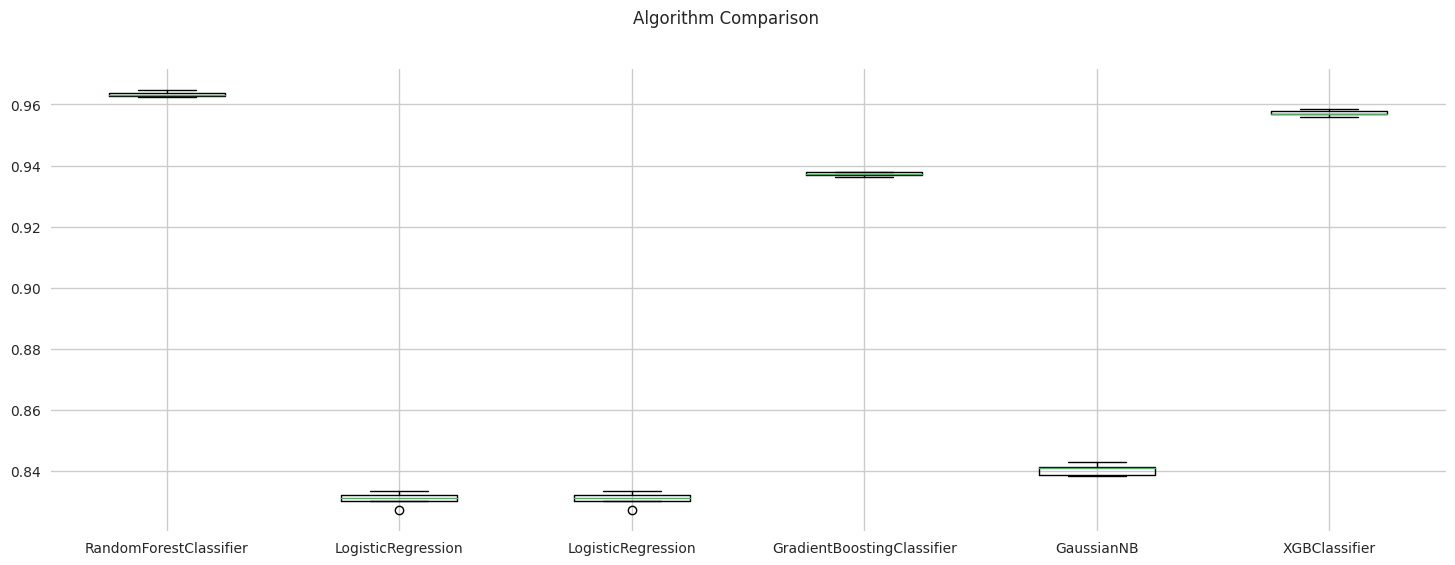

In [65]:
cv_results_array = []
for tt in results:
  cv_results_array.append(tt['test_score'])

fig = plt.figure(figsize=(18, 6))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(cv_results_array)
ax.set_xticklabels(names)
plt.show()

##**Evaluate Model**

In [66]:
display(model_results.style.background_gradient(cmap='summer_r'))

,Model Name,Train roc_auc Mean,Test roc_auc Mean,Fit Time Mean
0,RandomForestClassifier,1.000000,0.963310,50.687103
1,LogisticRegression,0.830923,0.830884,1.082271
2,LogisticRegression,0.830921,0.830882,2.394409
3,GradientBoostingClassifier,0.937867,0.937242,43.360494
4,GaussianNB,0.840480,0.840463,0.068730
5,XGBClassifier,0.965748,0.957140,2.394288


**RandomForest Classifier** ค่อนข้าง overfit <Br>
**XGBClassifier**  ได้ประสิทธิ์ภาพที่ดีกว่า



**XGBClassifier** Evaluation Metrics



In [67]:
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_test = XGBClassifier(random_state=55, nthread=-1)
xgb_test.fit(X_train, y_train, eval_metric=["auc", "logloss", "error"], eval_set=eval_set, verbose=False)

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:885: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, nthread=-1,
              num_parallel_tree=None, ...)

In [68]:
y_scores = xgb_test.predict(X_test)
roc_auc_score(y_test, y_scores)

0.6792690815864159

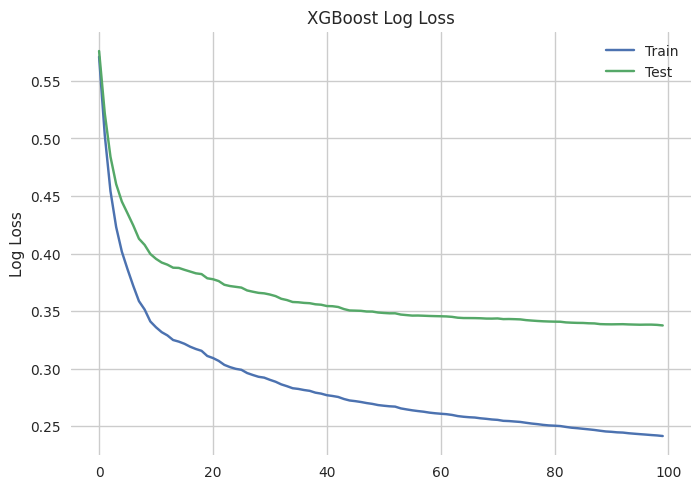

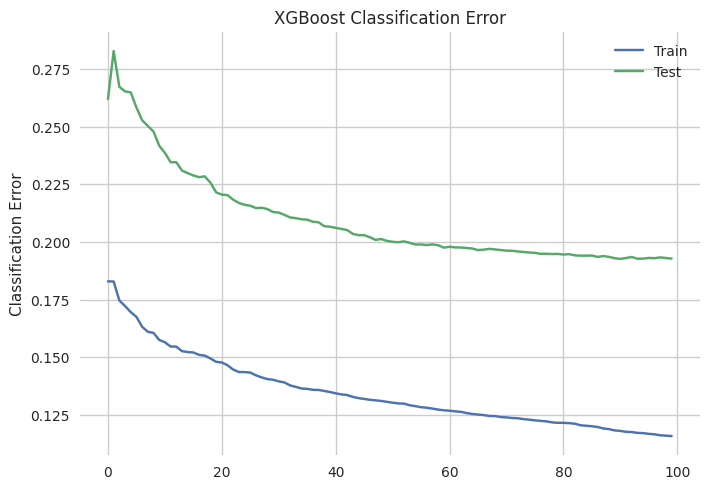

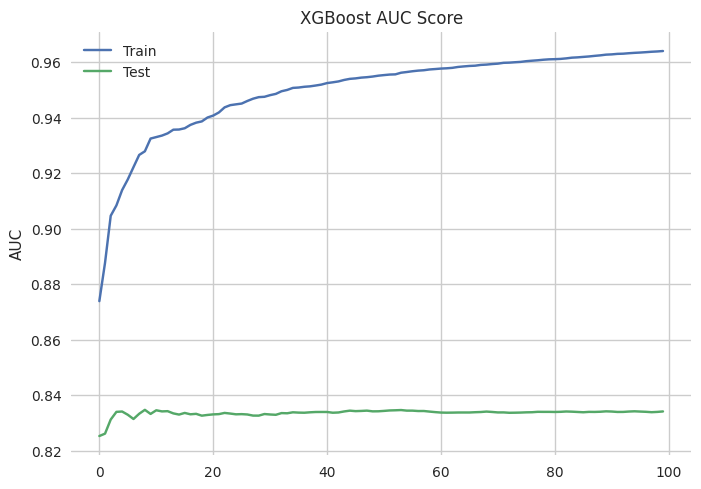

In [69]:
from matplotlib import pyplot
results = xgb_test.evals_result()
epochs = len(results['validation_0']['error'])
x_axis = range(0, epochs)
# plot log loss
fig, ax = pyplot.subplots()
ax.plot(x_axis, results['validation_0']['logloss'], label='Train')
ax.plot(x_axis, results['validation_1']['logloss'], label='Test')
ax.legend()
pyplot.ylabel('Log Loss')
pyplot.title('XGBoost Log Loss')
pyplot.show()
# plot classification error
fig, ax = pyplot.subplots()
ax.plot(x_axis, results['validation_0']['error'], label='Train')
ax.plot(x_axis, results['validation_1']['error'], label='Test')
ax.legend()
pyplot.ylabel('Classification Error')
pyplot.title('XGBoost Classification Error')
# plot auc
fig, ax = pyplot.subplots()
ax.plot(x_axis, results['validation_0']['auc'], label='Train')
ax.plot(x_axis, results['validation_1']['auc'], label='Test')
ax.legend()
pyplot.ylabel('AUC')
pyplot.title('XGBoost AUC Score')
pyplot.show()

##**ROC Curve**

**ROC** **(Receiver Operating Characteristic)**
 **Curve** เป็นเส้นที่ใช้วัดถึงประสิทธิภาพของโมเดลแบบ Classification ว่าสามารถทำนายประเด็นที่สนใจได้อย่างแม่นยำขนาดไหน(โดยทั่วไปนิยมวัดประสิทธิภาพของโมเดลแบบ Binary)

ส่วน AUC ก็คือ Area Under ROC Curve
หรือพื้นที่ใต้กราฟ ROC

In [70]:
gb_proba = xgb_test.predict_proba(X_test)[:,1]

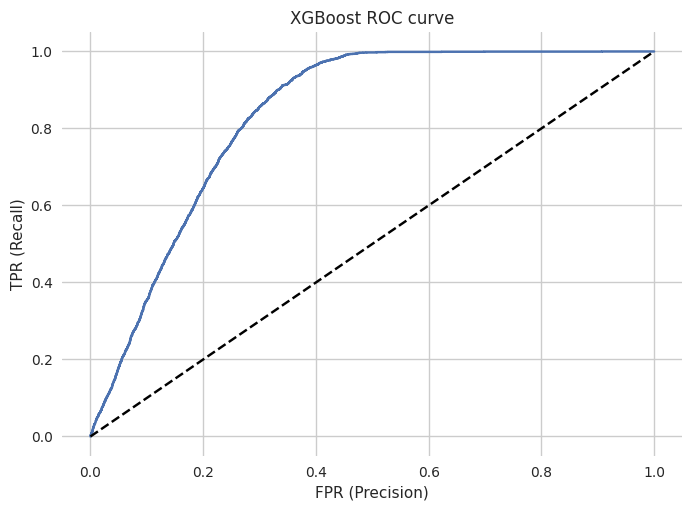

Area under curve (AUC):  0.83421


In [71]:
fpr, tpr, thresholds  = roc_curve(y_test, gb_proba)


plt.title('XGBoost ROC curve')
plt.xlabel('FPR (Precision)')
plt.ylabel('TPR (Recall)')

plt.plot(fpr,tpr)
plt.plot((0,1), ls='dashed',color='black')
plt.show()
print ('Area under curve (AUC): ', format(round(auc(fpr,tpr),5)))

##**Insights of Best Model**
Model ที่ให้ประสิทธิภาพสูงสุด : XGBoost Classifier

##**Classification Report**

In [72]:
from yellowbrick.classifier import ClassificationReport


def view_report(model,X,y):
    visualizer = ClassificationReport(
        model, classes=['0', '1'],
        cmap="YlGn", size=(600, 360)
    )
    visualizer.fit(X,y)
    visualizer.score(X,y)
    visualizer.show()

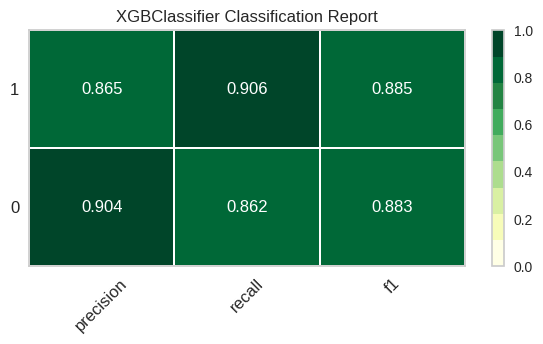

In [73]:
model = xgb_test
view_report(model, X_train, y_train)